<a href="https://colab.research.google.com/github/jadhavsiya481-hash/Python-Basic-Projects/blob/main/Assignment_19.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#2
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("train.csv")
print(df.head(10))


   Id  MSSubClass MSZoning  LotFrontage  LotArea Street Alley LotShape  \
0   1          60       RL         65.0     8450   Pave   NaN      Reg   
1   2          20       RL         80.0     9600   Pave   NaN      Reg   
2   3          60       RL         68.0    11250   Pave   NaN      IR1   
3   4          70       RL         60.0     9550   Pave   NaN      IR1   
4   5          60       RL         84.0    14260   Pave   NaN      IR1   
5   6          50       RL         85.0    14115   Pave   NaN      IR1   
6   7          20       RL         75.0    10084   Pave   NaN      Reg   
7   8          60       RL          NaN    10382   Pave   NaN      IR1   
8   9          50       RM         51.0     6120   Pave   NaN      Reg   
9  10         190       RL         50.0     7420   Pave   NaN      Reg   

  LandContour Utilities  ... PoolArea PoolQC  Fence MiscFeature MiscVal  \
0         Lvl    AllPub  ...        0    NaN    NaN         NaN       0   
1         Lvl    AllPub  ...       

In [2]:
missing = df.isnull().sum()
missing_percent = missing/len(df)*100
missing_df = pd.DataFrame({"missing values":missing,"missing percent":missing_percent})
print(missing_df[missing_df["missing values"]>0])

df = df.fillna(df.median(numeric_only=True))
df = df.fillna(df.mode().iloc[0])

print("Duplicate Rows:",df.duplicated().sum())
df = df.drop_duplicates()

              missing values  missing percent
LotFrontage              259        17.739726
Alley                   1369        93.767123
MasVnrType               872        59.726027
MasVnrArea                 8         0.547945
BsmtQual                  37         2.534247
BsmtCond                  37         2.534247
BsmtExposure              38         2.602740
BsmtFinType1              37         2.534247
BsmtFinType2              38         2.602740
Electrical                 1         0.068493
FireplaceQu              690        47.260274
GarageType                81         5.547945
GarageYrBlt               81         5.547945
GarageFinish              81         5.547945
GarageQual                81         5.547945
GarageCond                81         5.547945
PoolQC                  1453        99.520548
Fence                   1179        80.753425
MiscFeature             1406        96.301370
Duplicate Rows: 0


In [5]:
print(df.describe())

print("Minimum:",df["SalePrice"].min())
print("Maximum:",df["SalePrice"].max())
print("Mean:",df["SalePrice"].mean())
print("Median:",df["SalePrice"].median())

                Id   MSSubClass  LotFrontage        LotArea  OverallQual  \
count  1460.000000  1460.000000  1460.000000    1460.000000  1460.000000   
mean    730.500000    56.897260    69.863699   10516.828082     6.099315   
std     421.610009    42.300571    22.027677    9981.264932     1.382997   
min       1.000000    20.000000    21.000000    1300.000000     1.000000   
25%     365.750000    20.000000    60.000000    7553.500000     5.000000   
50%     730.500000    50.000000    69.000000    9478.500000     6.000000   
75%    1095.250000    70.000000    79.000000   11601.500000     7.000000   
max    1460.000000   190.000000   313.000000  215245.000000    10.000000   

       OverallCond    YearBuilt  YearRemodAdd   MasVnrArea   BsmtFinSF1  ...  \
count  1460.000000  1460.000000   1460.000000  1460.000000  1460.000000  ...   
mean      5.575342  1971.267808   1984.865753   103.117123   443.639726  ...   
std       1.112799    30.202904     20.645407   180.731373   456.098091  ..

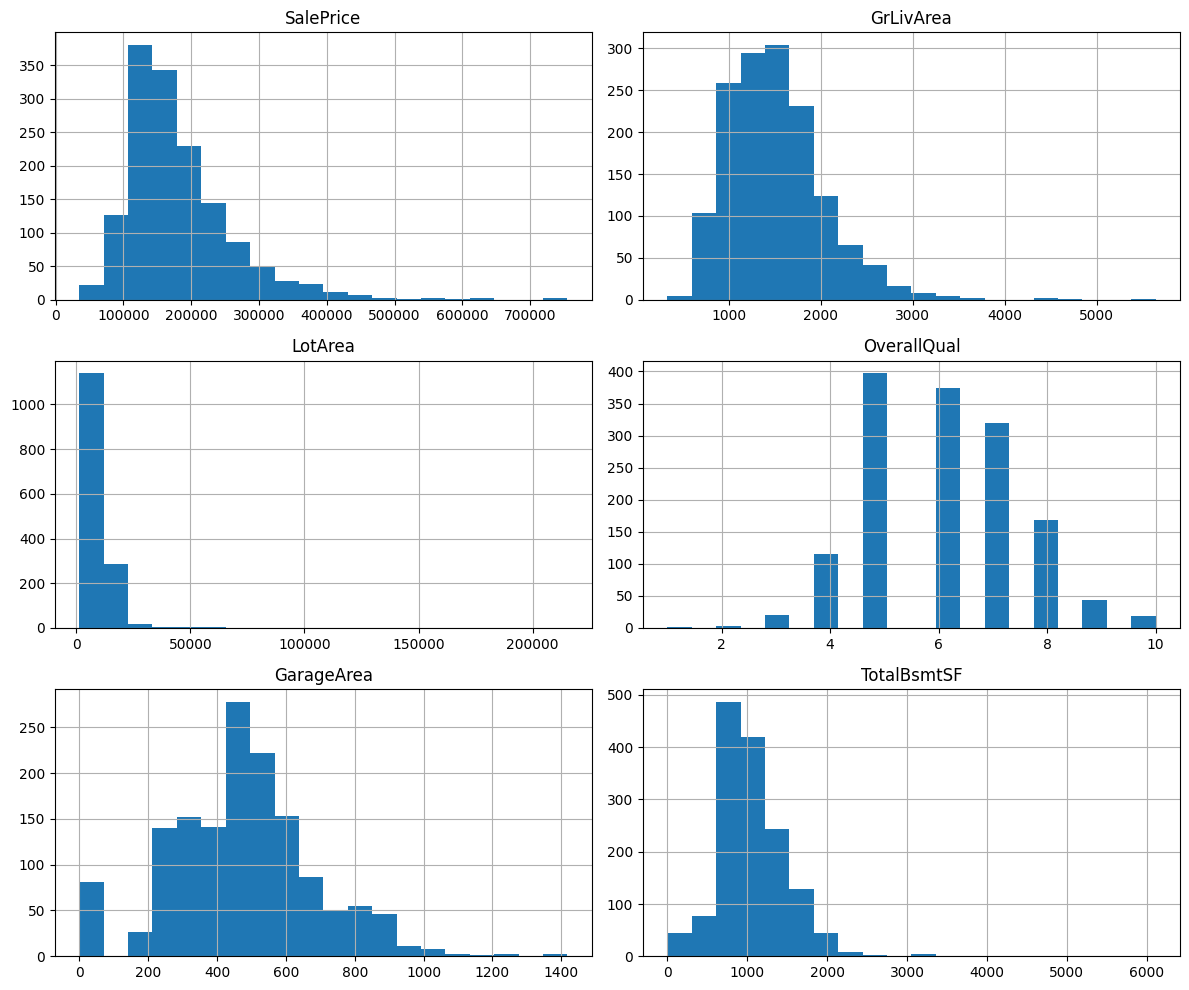

In [7]:
important_cols = ['SalePrice','GrLivArea','LotArea','OverallQual','GarageArea','TotalBsmtSF']
df[important_cols].hist(figsize=(12,10),bins=20)
plt.tight_layout()
plt.show()

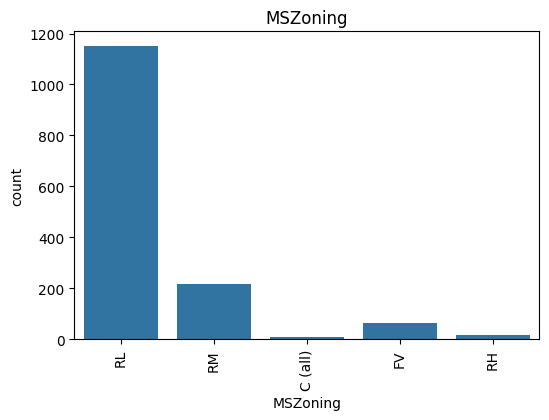

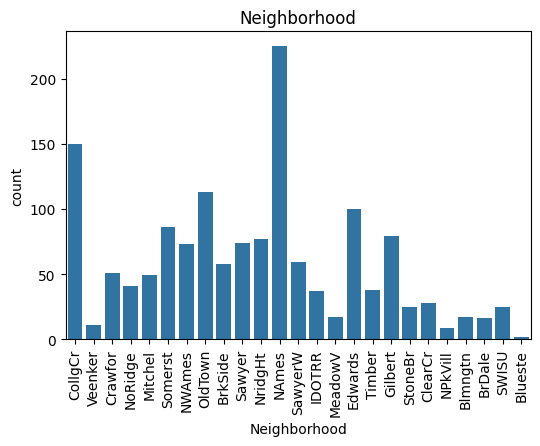

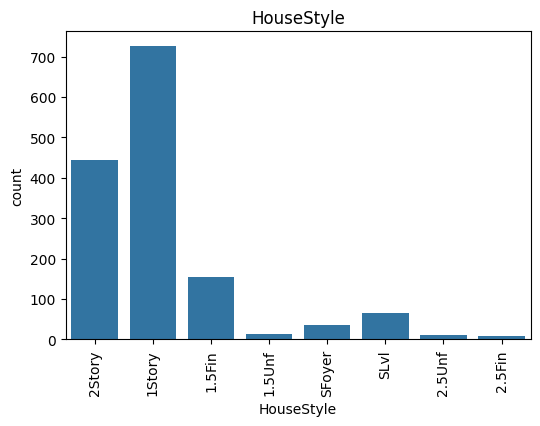

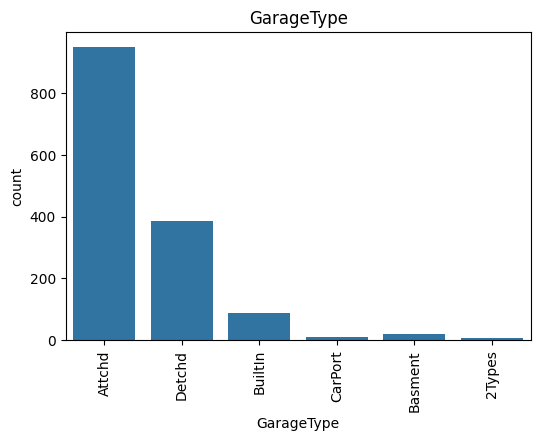

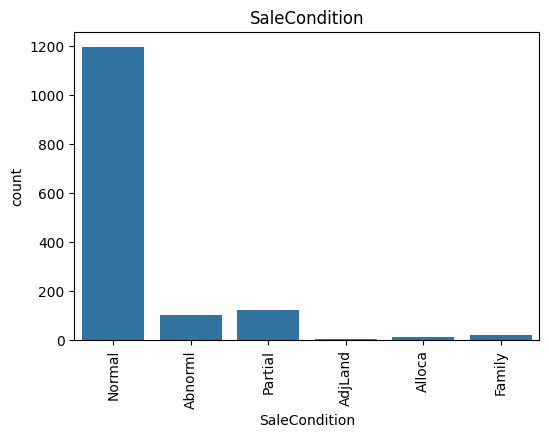

In [11]:
import seaborn as sns

important_cols = ['MSZoning','Neighborhood','HouseStyle','GarageType','SaleCondition']
for col in important_cols:
  plt.figure(figsize=(6,4))
  sns.countplot(x=col, data=df)
  plt.xticks(rotation=90)
  plt.title(col)
  plt.show()

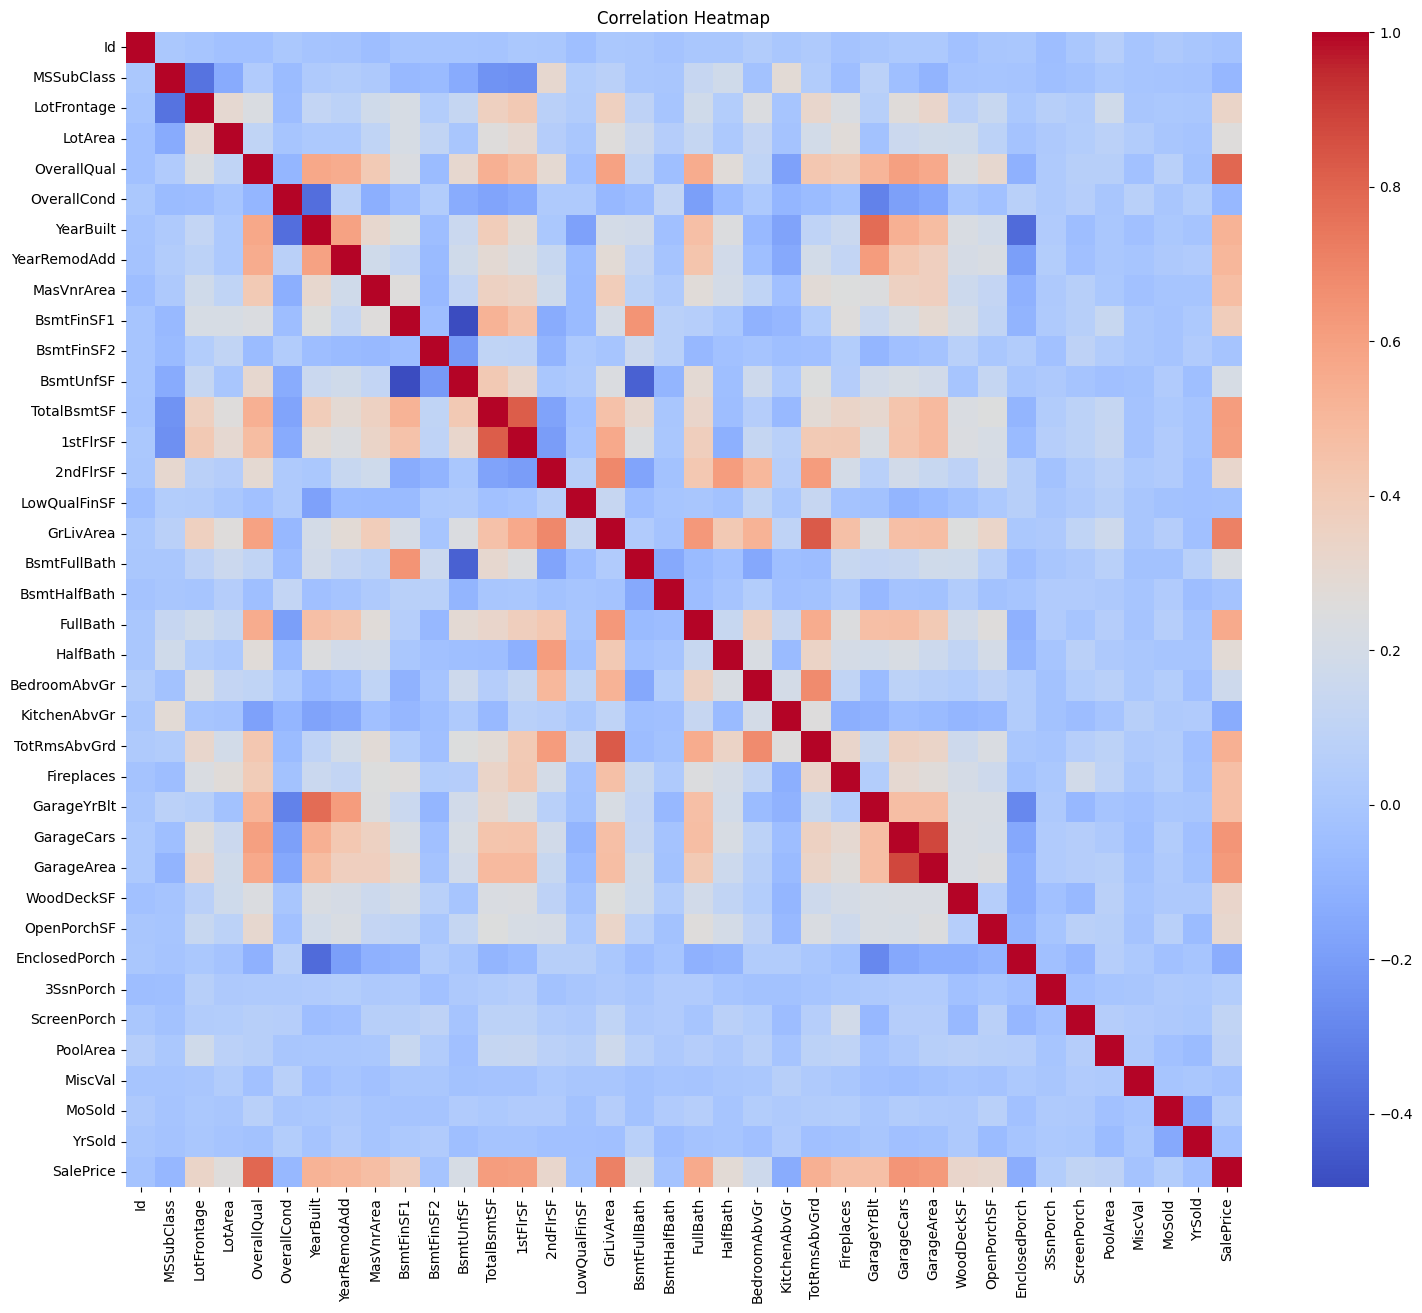

In [14]:
import seaborn as sns

plt.figure(figsize=(18,15))
sns.heatmap(df.corr(numeric_only=True),cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In [15]:
X = df.drop("SalePrice",axis=1)
Y = df["SalePrice"]

print("Independent Features:")
print(X.columns)

print("Dependent Features:")
print(Y.name)

Independent Features:
Index(['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig',
       'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
       'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd',
       'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
       'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1',
       'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual',
       'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType',
       'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual',
       'Ga

In [17]:
print("Before Encoding")
print(df[["MSZoning","Street"]].head())

encoded_df = pd.get_dummies(df, columns=["MSZoning","Street"],drop_first=True)

print("After Encoding")
print(encoded_df.filter(regex="MSZoning|Street").head())

Before Encoding
  MSZoning Street
0       RL   Pave
1       RL   Pave
2       RL   Pave
3       RL   Pave
4       RL   Pave
After Encoding
   MSZoning_FV  MSZoning_RH  MSZoning_RL  MSZoning_RM  Street_Pave
0        False        False         True        False         True
1        False        False         True        False         True
2        False        False         True        False         True
3        False        False         True        False         True
4        False        False         True        False         True


In [25]:
print(df.dtypes)

Id                 int64
MSSubClass         int64
MSZoning          object
LotFrontage      float64
LotArea            int64
                  ...   
MoSold             int64
YrSold             int64
SaleType          object
SaleCondition     object
SalePrice          int64
Length: 81, dtype: object


In [27]:
from sklearn.preprocessing import StandardScaler
import pandas as pd

encoded_df = pd.get_dummies(df, drop_first=True, dtype=int)

X = encoded_df.drop("SalePrice", axis=1)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
scaled_df = pd.DataFrame(X_scaled, columns=X.columns)
print(scaled_df.head())

         Id  MSSubClass  LotFrontage   LotArea  OverallQual  OverallCond  \
0 -1.730865    0.073375    -0.220875 -0.207142     0.651479    -0.517200   
1 -1.728492   -0.872563     0.460320 -0.091886    -0.071836     2.179628   
2 -1.726120    0.073375    -0.084636  0.073480     0.651479    -0.517200   
3 -1.723747    0.309859    -0.447940 -0.096897     0.651479    -0.517200   
4 -1.721374    0.073375     0.641972  0.375148     1.374795    -0.517200   

   YearBuilt  YearRemodAdd  MasVnrArea  BsmtFinSF1  ...  SaleType_ConLI  \
0   1.050994      0.878668    0.514104    0.575425  ...       -0.058621   
1   0.156734     -0.429577   -0.570750    1.171992  ...       -0.058621   
2   0.984752      0.830215    0.325915    0.092907  ...       -0.058621   
3  -1.863632     -0.720298   -0.570750   -0.499274  ...       -0.058621   
4   0.951632      0.733308    1.366489    0.463568  ...       -0.058621   

   SaleType_ConLw  SaleType_New  SaleType_Oth  SaleType_WD  \
0       -0.058621     -0.30196